## Fase 1: Geração e Validação de Dados Brutos
Nesta etapa, utilizamos a engine do DuckDB para gerar 10.000 registros simulados de telemetria de rede e salvar diretamente no formato colunar `.parquet`. Abaixo, validamos a estrutura desse arquivo.

In [1]:
import duckdb

# Lendo o arquivo parquet e exibindo os 5 primeiros registros
duckdb.sql("SELECT * FROM 'raw_telemetry.parquet' LIMIT 5").show()

┌──────────┬─────────────┬───────────┬───────────────────────────────┬────────────┬─────────────────┬───────────────────┐
│ event_id │ customer_id │ router_id │        event_timestamp        │ latency_ms │ packet_loss_pct │ connection_status │
│ varchar  │    int32    │  varchar  │   timestamp with time zone    │   int32    │     double      │      varchar      │
├──────────┼─────────────┼───────────┼───────────────────────────────┼────────────┼─────────────────┼───────────────────┤
│ EVT-0    │          53 │ NODE-2.0  │ 2026-09-17 20:39:38.599259+00 │         83 │            4.94 │ Online            │
│ EVT-1    │         341 │ NODE-6.0  │ 2026-08-31 20:39:38.599259+00 │         42 │            1.36 │ Online            │
│ EVT-2    │         390 │ NODE-10.0 │ 2026-09-15 20:39:38.599259+00 │        117 │            4.77 │ Online            │
│ EVT-3    │         156 │ NODE-10.0 │ 2026-09-18 20:39:38.599259+00 │        106 │            3.92 │ Online            │
│ EVT-4    │          37

## Fase 2: A Camada Staging e a Mágica do dbt
Na etapa anterior, orquestramos nosso primeiro modelo executando `dbt run`. O dbt compilou o nosso código declarativo e materializou uma **View** diretamente no DuckDB. 

Abaixo, validamos o resultado do nosso "filtro de pureza". Podemos observar a padronização dos nomes das colunas e a criação on-the-fly da flag de negócio `is_sla_breached`, que será fundamental para as análises de qualidade de rede e risco de churn.

In [2]:
import duckdb

# Conectando ao banco de dados persistente que o dbt orquestrou
con = duckdb.connect('telco.duckdb')

# Consultando a View stg_telemetry gerada pelo dbt
con.sql("SELECT * FROM stg_telemetry LIMIT 5").show()

# Fechando a conexão para evitar travamentos (best practice)
con.close()

┌──────────┬─────────────┬───────────┬───────────────────────────────┬────────────┬─────────────────┬───────────────────┬─────────────────┐
│ event_id │ customer_id │ router_id │       event_created_at        │ latency_ms │ packet_loss_pct │ connection_status │ is_sla_breached │
│ varchar  │    int32    │  varchar  │   timestamp with time zone    │   int32    │     double      │      varchar      │     boolean     │
├──────────┼─────────────┼───────────┼───────────────────────────────┼────────────┼─────────────────┼───────────────────┼─────────────────┤
│ EVT-0    │          53 │ NODE-2.0  │ 2026-09-17 20:39:38.599259+00 │         83 │            4.94 │ Online            │ false           │
│ EVT-1    │         341 │ NODE-6.0  │ 2026-08-31 20:39:38.599259+00 │         42 │            1.36 │ Online            │ false           │
│ EVT-2    │         390 │ NODE-10.0 │ 2026-09-15 20:39:38.599259+00 │        117 │            4.77 │ Online            │ false           │
│ EVT-3    │        

## Fase3: Camada Marts e Inteligência de Negócio
Com a fundação do Staging pronta, construímos o nosso primeiro Data Mart (`agg_router_health`). Utilizámos a função `ref()` do dbt para criar uma dependência direta entre os modelos.
O resultado abaixo consolida 10.000 registos brutos em métricas executivas, ordenando os roteadores pela taxa crítica de falha de SLA.

In [1]:
import duckdb

con = duckdb.connect('telco.duckdb')
# Consultando o nosso Data Mart e ordenando pelos piores roteadores
con.sql("SELECT * FROM agg_router_health ORDER BY sla_breach_rate_pct DESC").show()
con.close()

┌───────────┬──────────────┬────────────────┬─────────────────────┬────────────────────┬─────────────────────┐
│ router_id │ total_events │ avg_latency_ms │ avg_packet_loss_pct │ total_sla_breaches │ sla_breach_rate_pct │
│  varchar  │    int64     │     double     │       double        │       int128       │       double        │
├───────────┼──────────────┼────────────────┼─────────────────────┼────────────────────┼─────────────────────┤
│ NODE-4.0  │          977 │           78.1 │                2.55 │                211 │                21.6 │
│ NODE-8.0  │         1025 │          76.07 │                2.55 │                219 │               21.37 │
│ NODE-2.0  │          964 │          76.31 │                2.48 │                193 │               20.02 │
│ NODE-1.0  │          963 │           76.4 │                2.54 │                191 │               19.83 │
│ NODE-9.0  │          988 │          75.89 │                2.51 │                195 │               19.74 │
│

# Fase 4: Consumo Analítico e Visualização Executiva (Python & Seaborn)
Consumo direto do Data Mart `agg_router_health` compilado pelo dbt no DuckDB para diagnóstico operacional de SLA de rede.

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do estilo visual executivo
sns.set_theme(style="whitegrid", palette="muted")

# Conexão ao banco local gerado pelo dbt
con = duckdb.connect("telco.duckdb", read_only=True)

query = """
SELECT 
    router_id,
    total_events,
    avg_latency_ms,
    avg_packet_loss_pct,
    total_sla_breaches,
    sla_breach_rate_pct
FROM agg_router_health
ORDER BY sla_breach_rate_pct DESC;
"""

df_health = con.execute(query).df()
con.close()

df_health

,router_id,total_events,avg_latency_ms,avg_packet_loss_pct,total_sla_breaches,sla_breach_rate_pct
0,NODE-4.0,977,78.10,2.55,211.0,21.60
1,NODE-8.0,1025,76.07,2.55,219.0,21.37
2,NODE-2.0,964,76.31,2.48,193.0,20.02
3,NODE-1.0,963,76.40,2.54,191.0,19.83
4,NODE-9.0,988,75.89,2.51,195.0,19.74
5,NODE-10.0,994,76.34,2.50,190.0,19.11
6,NODE-3.0,1036,76.02,2.45,192.0,18.53
7,NODE-5.0,990,78.34,2.48,181.0,18.28
8,NODE-6.0,1041,76.85,2.51,184.0,17.68
9,NODE-7.0,1022,79.49,2.50,180.0,17.61


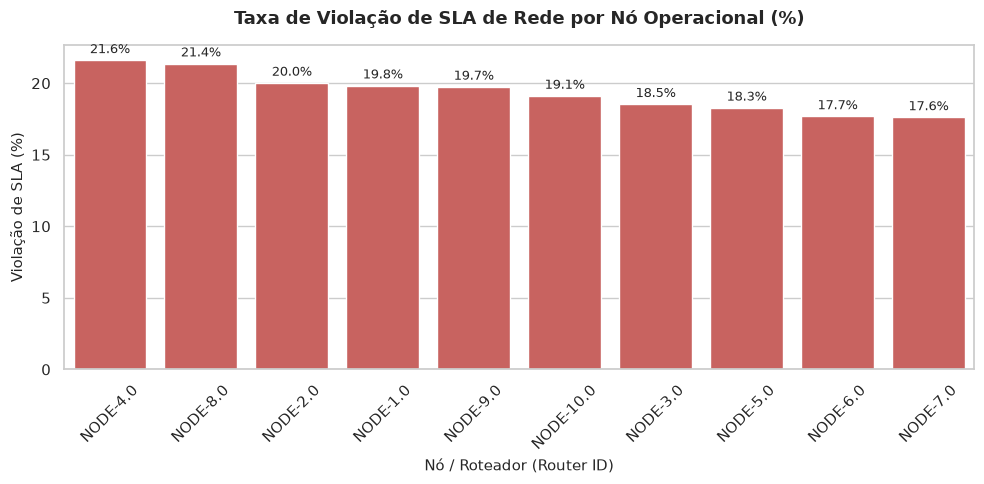

In [3]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df_health,
    x="router_id",
    y="sla_breach_rate_pct",
    color="#d9534f"
)

plt.title("Taxa de Violação de SLA de Rede por Nó Operacional (%)", fontsize=13, pad=15, weight="bold")
plt.xlabel("Nó / Roteador (Router ID)", fontsize=11)
plt.ylabel("Violação de SLA (%)", fontsize=11)
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.savefig("sla_breach_ranking.png", dpi=300)
plt.show()

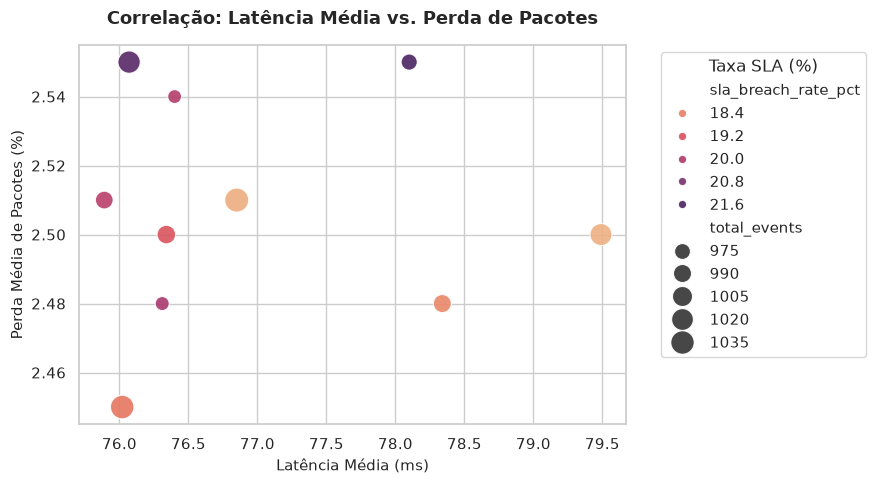

In [4]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df_health,
    x="avg_latency_ms",
    y="avg_packet_loss_pct",
    size="total_events",
    hue="sla_breach_rate_pct",
    palette="flare",
    sizes=(100, 300),
    alpha=0.9
)

plt.title("Correlação: Latência Média vs. Perda de Pacotes", fontsize=13, pad=15, weight="bold")
plt.xlabel("Latência Média (ms)", fontsize=11)
plt.ylabel("Perda Média de Pacotes (%)", fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Taxa SLA (%)")

plt.tight_layout()
plt.savefig("latency_vs_loss_correlation.png", dpi=300)
plt.show()